In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.metrics import BinaryAccuracy, FalsePositives, FalseNegatives, TruePositives, TrueNegatives, Precision, Recall, AUC
from tqdm import tqdm
import os
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard, ModelCheckpoint
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')

All libraries imported successfully!
TensorFlow version: 2.19.0


In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
# Dataset path for Lung Cancer
dataset_path = '/content/drive/MyDrive/Lung Dataset-20260126T115935Z-1-001/Lung Dataset'

# Get class labels from directory
labels = sorted(os.listdir(dataset_path))
print(f'Classes found: {labels}')
print(f'Number of classes: {len(labels)}')

# Image configuration
image_size = 224
print(f'Image size: {image_size}x{image_size}')

Classes found: ['Benign', 'Malignant', 'Normal']
Number of classes: 3
Image size: 224x224


In [4]:
# Load all images
X_train = []
Y_train = []

print('Loading images from dataset...')
for label in labels:
    label_path = os.path.join(dataset_path, label)
    print(f'\nLoading class: {label}')

    for file in tqdm(os.listdir(label_path)):
        try:
            image_path = os.path.join(label_path, file)
            image = cv2.imread(image_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, (image_size, image_size))
            X_train.append(image)
            Y_train.append(label)
        except Exception as e:
            print(f'Error loading {file}: {e}')
            continue

X_train = np.array(X_train)
print(f'\nTotal images loaded: {len(X_train)}')
print(f'Image shape: {X_train.shape}')

Loading images from dataset...

Loading class: Benign


100%|██████████| 120/120 [00:06<00:00, 17.77it/s]



Loading class: Malignant


100%|██████████| 561/561 [00:13<00:00, 40.42it/s]



Loading class: Normal


100%|██████████| 416/416 [00:14<00:00, 29.42it/s]


Total images loaded: 1097
Image shape: (1097, 224, 224, 3)


In [5]:
# Shuffle the dataset
X_train, Y_train = shuffle(X_train, Y_train, random_state=42)
print('Data shuffled successfully!')

Data shuffled successfully!


In [6]:
# Split into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X_train, Y_train, test_size=0.2, random_state=42, stratify=Y_train
)

print(f'Training samples: {len(X_train)}')
print(f'Testing samples: {len(X_test)}')

Training samples: 877
Testing samples: 220


In [7]:
# Encode labels to integers
y_train_ = []
for i in Y_train:
    y_train_.append(labels.index(i))
Y_train = y_train_

y_test_ = []
for i in Y_test:
    y_test_.append(labels.index(i))
Y_test = y_test_

# Convert to categorical (one-hot encoding)
Y_train = tf.keras.utils.to_categorical(Y_train, num_classes=len(labels))
Y_test = tf.keras.utils.to_categorical(Y_test, num_classes=len(labels))

print(f'Label encoding completed!')
print(f'Y_train shape: {Y_train.shape}')
print(f'Y_test shape: {Y_test.shape}')

Label encoding completed!
Y_train shape: (877, 3)
Y_test shape: (220, 3)


In [8]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Flatten, BatchNormalization, Dense, Dropout
from tensorflow.keras.layers import MaxPooling2D

print('Model libraries imported!')

Model libraries imported!


In [9]:
# Load ResNet50 pre-trained on ImageNet
resnet50 = ResNet50(
    input_shape=(224, 224, 3),
    weights='imagenet',
    include_top=False
)

# Freeze base model layers
for layer in resnet50.layers:
    layer.trainable = False

print('ResNet50 base model loaded successfully!')
print(f'Total layers in ResNet50: {len(resnet50.layers)}')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 base model loaded successfully!
Total layers in ResNet50: 175


In [10]:
# Build custom classification head on top of ResNet50
x = GlobalAveragePooling2D()(resnet50.output)
x = Dropout(rate=0.5)(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(rate=0.4)(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(rate=0.3)(x)
x = BatchNormalization()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(rate=0.2)(x)
x = BatchNormalization()(x)
prediction = Dense(len(labels), activation='softmax', name='output_layer')(x)

# Create the complete model
model = Model(inputs=resnet50.inputs, outputs=prediction)

print('Complete model built successfully!')
print(f'Number of classes: {len(labels)}')

Complete model built successfully!
Number of classes: 3


In [11]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,813,187 (94.65 MB)

 Trainable params: 1,219,587 (4.65 MB)

 Non-trainable params: 23,593,600 (90.00 MB)

In [12]:
# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print('Model compiled successfully!')

Model compiled successfully!


In [13]:
# Define callbacks
checkpoint = ModelCheckpoint(
    "GradCAM_ResNet50_LungCancer.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="auto",
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=2,
    min_delta=0.0001,
    mode='auto',
    verbose=1
)

print('Callbacks configured!')

Callbacks configured!


In [14]:
# Train the model
print('Starting model training...')
history = model.fit(
    X_train, Y_train,
    validation_split=0.1,
    epochs=20,
    verbose=1,
    batch_size=32,
    callbacks=[checkpoint, reduce_lr]
)

print('\nTraining completed!')

Starting model training...
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.5921 - loss: 0.9403
Epoch 1: val_accuracy improved from -inf to 0.87500, saving model to GradCAM_ResNet50_LungCancer.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 832ms/step - accuracy: 0.5967 - loss: 0.9312 - val_accuracy: 0.8750 - val_loss: 0.3299 - learning_rate: 0.0010
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8615 - loss: 0.3625
Epoch 2: val_accuracy improved from 0.87500 to 0.90909, saving model to GradCAM_ResNet50_LungCancer.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 110ms/step - accuracy: 0.8618 - loss: 0.3628 - val_accuracy: 0.9091 - val_loss: 0.2839 - learning_rate: 0.0010
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8637 - loss: 0.3266
Epoch 3: val_accuracy did not improve from 0.90909
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.8638 - loss: 0.3269 - val_accuracy: 0.8977 - val_loss: 0.2483 - learning_rate: 0.0010
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8979 - loss: 0.2771
Epoch 4: val_accuracy improved from 0.90909 to 0.93182, saving model to GradCAM_ResNet50_LungCancer.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - accuracy: 0.8981 - loss: 0.2771 - val_accuracy: 0.9318 - val_loss: 0.2260 - learning_rate: 0.0010
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8761 - loss: 0.2778
Epoch 5: val_accuracy did not improve from 0.93182
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.8767 - loss: 0.2776 - val_accuracy: 0.9091 - val_loss: 0.1989 - learning_rate: 0.0010
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9087 - loss: 0.2084
Epoch 6: val_accuracy did not improve from 0.93182

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.9089 - loss: 0.2087 - val_accuracy: 0.9318 - val_loss: 0.1870 - learning_rate: 0.0010
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9204 - loss: 0.1986
Epoch 7: val_accuracy did not improve from 0.93182
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.9204 - loss: 0.1990 - val_accuracy: 0.92

25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 0.9299 - loss: 0.1481 - val_accuracy: 0.9432 - val_loss: 0.1671 - learning_rate: 3.1250e-05
Epoch 16/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9176 - loss: 0.2149
Epoch 16: val_accuracy did not improve from 0.94318
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.9181 - loss: 0.2136 - val_accuracy: 0.9432 - val_loss: 0.1667 - learning_rate: 3.1250e-05
Epoch 17/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9403 - loss: 0.1584
Epoch 17: val_accuracy did not improve from 0.94318

Epoch 17: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.9399 - loss: 0.1591 - val_accuracy: 0.9432 - val_loss: 0.1662 - learning_rate: 3.1250e-05
Epoch 18/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9324 - loss: 0.1845
Epoch 18: val_accuracy did not improve from 0.94318
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.9330 - loss: 0.1830 

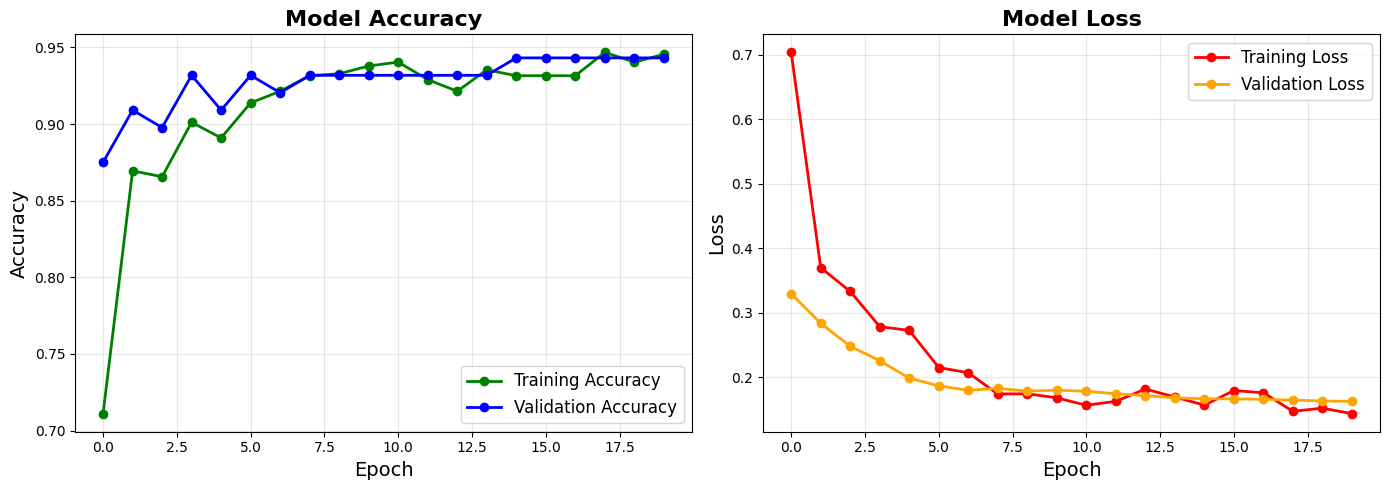

In [16]:
# Plot training history
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], 'o-g', linewidth=2, label='Training Accuracy')
plt.plot(history.history['val_accuracy'], 'o-b', linewidth=2, label='Validation Accuracy')
plt.title('Model Accuracy', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3);

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], 'o-r', linewidth=2, label='Training Loss')
plt.plot(history.history['val_loss'], 'o-', color='orange', linewidth=2, label='Validation Loss')
plt.title('Model Loss', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3);

plt.tight_layout()
plt.show()

In [17]:
# Save the trained model
model.save("ResNet50_LungCancer_GradCAM.h5")
print("Model saved to disk: ResNet50_LungCancer_GradCAM.h5")

Model saved to disk: ResNet50_LungCancer_GradCAM.h5


In [18]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, Y_test, verbose=1)
print(f'\nTest Accuracy: {test_accuracy:.4f}')
print(f'Test Loss: {test_loss:.4f}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 982ms/step - accuracy: 0.9498 - loss: 0.1682

Test Accuracy: 0.9545
Test Loss: 0.1311


Loading image: /content/drive/MyDrive/Lung Dataset-20260126T115935Z-1-001/Lung Dataset/Benign/Bengin case (63).jpg
Original image shape: (512, 512, 3)


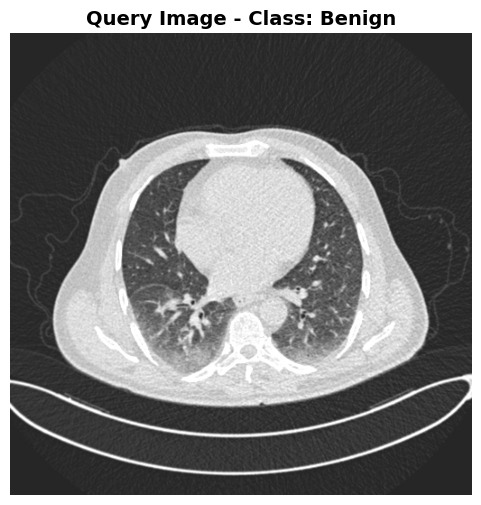

Resized image shape: (224, 224, 3)


In [19]:
# Load a sample image from your dataset for GradCAM visualization
sample_class = labels[0]  # First class
sample_image_path = os.path.join(dataset_path, sample_class)
sample_files = os.listdir(sample_image_path)

if sample_files:
    query_image_path = os.path.join(sample_image_path, sample_files[0])
    print(f'Loading image: {query_image_path}')

    # Load and display the image
    image = load_img(query_image_path)
    image = np.array(image)
    print(f"Original image shape: {image.shape}")

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(f'Query Image - Class: {sample_class}', fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

    # Resize for model input
    query_image = cv2.resize(image, (224, 224), interpolation=cv2.INTER_AREA)
    print(f'Resized image shape: {query_image.shape}')
else:
    print('No sample images found!')

In [20]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Generate GradCAM heatmap using TensorFlow 2.x with eager execution.

    Args:
        img_array: Input image (preprocessed)
        model: Trained Keras model
        last_conv_layer_name: Name of the last convolutional layer
        pred_index: Index of class to visualize (None = use predicted class)

    Returns:
        heatmap: GradCAM heatmap as numpy array
    """
    # Create a model that maps the input image to the activations of the last conv layer
    # and the output predictions
    grad_model = keras.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen)
    # with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient
    # over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array
    # by "how important this channel is" with regard to the top predicted class
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will also normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

print('GradCAM function defined successfully!')

GradCAM function defined successfully!


In [21]:
# Find all convolutional layers in the model
conv_layers = []
for layer in model.layers:
    if 'conv' in layer.name.lower():
        conv_layers.append(layer.name)

print('Convolutional layers found:')
for i, layer_name in enumerate(conv_layers[-10:]):  # Show last 10
    print(f'  {layer_name}')

# Use the last convolutional layer
last_conv_layer_name = conv_layers[-1] if conv_layers else 'conv5_block3_out'
print(f'\nUsing layer for GradCAM: {last_conv_layer_name}')

Convolutional layers found:
  conv5_block3_1_conv
  conv5_block3_1_bn
  conv5_block3_1_relu
  conv5_block3_2_conv
  conv5_block3_2_bn
  conv5_block3_2_relu
  conv5_block3_3_conv
  conv5_block3_3_bn
  conv5_block3_add
  conv5_block3_out

Using layer for GradCAM: conv5_block3_out


In [22]:
# Prepare image for GradCAM
img_array = np.expand_dims(query_image, axis=0)

# Make prediction
preds = model.predict(img_array)
pred_class = np.argmax(preds[0])
print(f'Predicted class: {labels[pred_class]}')
print(f'Confidence: {preds[0][pred_class]:.4f}')
print(f'\nAll predictions:')
for i, label in enumerate(labels):
    print(f'  {label}: {preds[0][i]:.4f}')

# Generate GradCAM heatmap
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
print(f'\nHeatmap shape: {heatmap.shape}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Predicted class: Benign
Confidence: 0.9744

All predictions:
  Benign: 0.9744
  Malignant: 0.0160
  Normal: 0.0097

Heatmap shape: (7, 7)


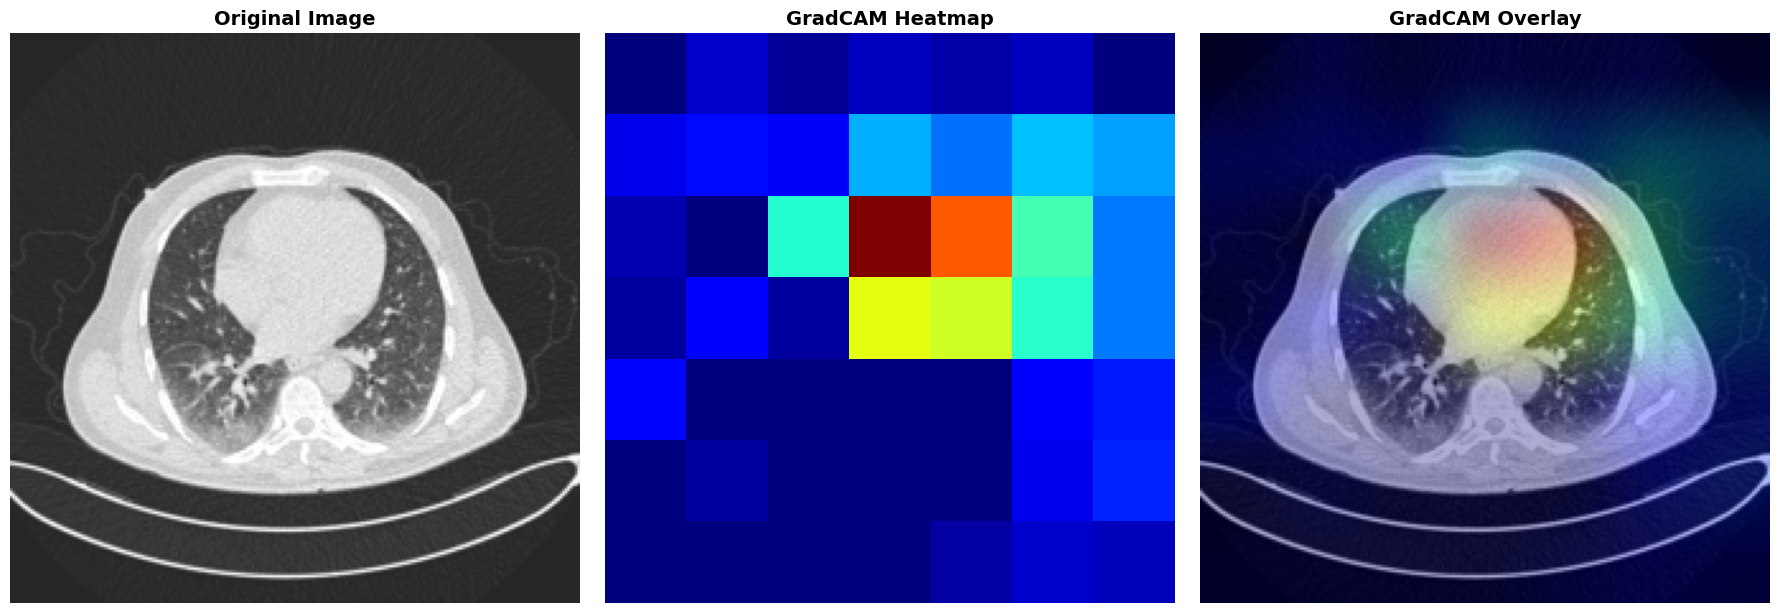

In [23]:
def display_gradcam(img, heatmap, alpha=0.4):
    """
    Display GradCAM visualization.

    Args:
        img: Original image
        heatmap: GradCAM heatmap
        alpha: Transparency for overlay
    """
    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = plt.cm.get_cmap("jet")

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.preprocessing.image.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = keras.preprocessing.image.array_to_img(superimposed_img)

    # Display
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(img.astype('uint8'))
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title('GradCAM Heatmap', fontsize=14, fontweight='bold')
    axes[1].axis('off')

    axes[2].imshow(superimposed_img)
    axes[2].set_title('GradCAM Overlay', fontsize=14, fontweight='bold')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Display the GradCAM visualization
display_gradcam(query_image, heatmap)

In [24]:
def visualize_gradcam_for_image(image_path, model, last_conv_layer_name, class_names):
    """
    Complete pipeline to load an image, generate GradCAM, and visualize.

    Args:
        image_path: Path to the image file
        model: Trained Keras model
        last_conv_layer_name: Name of last convolutional layer
        class_names: List of class names
    """
    # Load image
    img = load_img(image_path)
    img = np.array(img)

    # Resize
    img_resized = cv2.resize(img, (224, 224))
    img_array = np.expand_dims(img_resized, axis=0)

    # Predict
    preds = model.predict(img_array, verbose=0)
    pred_class = np.argmax(preds[0])

    print(f'Image: {os.path.basename(image_path)}')
    print(f'Predicted: {class_names[pred_class]} (confidence: {preds[0][pred_class]:.4f})')

    # Generate GradCAM
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

    # Display
    display_gradcam(img_resized, heatmap)

print('Visualization function defined!')

Visualization function defined!


In [25]:
# Visualize GradCAM for multiple samples from each class
print('Generating GradCAM visualizations for each class...')
print('='*80)

num_samples_per_class = 2

for label in labels:
    print(f'\nClass: {label}')
    print('-'*80)

    class_path = os.path.join(dataset_path, label)
    class_files = os.listdir(class_path)[:num_samples_per_class]

    for file in class_files:
        image_path = os.path.join(class_path, file)
        try:
            visualize_gradcam_for_image(image_path, model, last_conv_layer_name, labels)
        except Exception as e:
            print(f'Error processing {file}: {e}')
            continue

print('\n' + '='*80)
print('GradCAM visualization completed!')

Output hidden; open in https://colab.research.google.com to view.

In [26]:
def batch_gradcam_visualization(image_paths, model, last_conv_layer_name, class_names):
    """
    Generate GradCAM for multiple images in a grid.

    Args:
        image_paths: List of image file paths
        model: Trained Keras model
        last_conv_layer_name: Name of last convolutional layer
        class_names: List of class names
    """
    num_images = len(image_paths)
    fig, axes = plt.subplots(num_images, 3, figsize=(15, 5 * num_images))

    if num_images == 1:
        axes = axes.reshape(1, -1)

    for idx, image_path in enumerate(image_paths):
        # Load and process image
        img = load_img(image_path)
        img = np.array(img)
        img_resized = cv2.resize(img, (224, 224))
        img_array = np.expand_dims(img_resized, axis=0)

        # Predict
        preds = model.predict(img_array, verbose=0)
        pred_class = np.argmax(preds[0])

        # Generate GradCAM
        heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

        # Prepare overlay
        heatmap_uint8 = np.uint8(255 * heatmap)
        jet = plt.cm.get_cmap("jet")
        jet_colors = jet(np.arange(256))[:, :3]
        jet_heatmap = jet_colors[heatmap_uint8]
        jet_heatmap = keras.preprocessing.image.array_to_img(jet_heatmap)
        jet_heatmap = jet_heatmap.resize((224, 224))
        jet_heatmap = keras.preprocessing.image.img_to_array(jet_heatmap)
        superimposed_img = jet_heatmap * 0.4 + img_resized

        # Plot
        axes[idx, 0].imshow(img_resized.astype('uint8'))
        axes[idx, 0].set_title(f'{class_names[pred_class]} ({preds[0][pred_class]:.2f})', fontsize=10)
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(heatmap_uint8, cmap='jet')
        axes[idx, 1].set_title('Heatmap', fontsize=10)
        axes[idx, 1].axis('off')

        axes[idx, 2].imshow(superimposed_img.astype('uint8'))
        axes[idx, 2].set_title('Overlay', fontsize=10)
        axes[idx, 2].axis('off')

    plt.tight_layout()
    plt.show()

print('Batch visualization function defined!')

Batch visualization function defined!


Comparing GradCAM across classes...


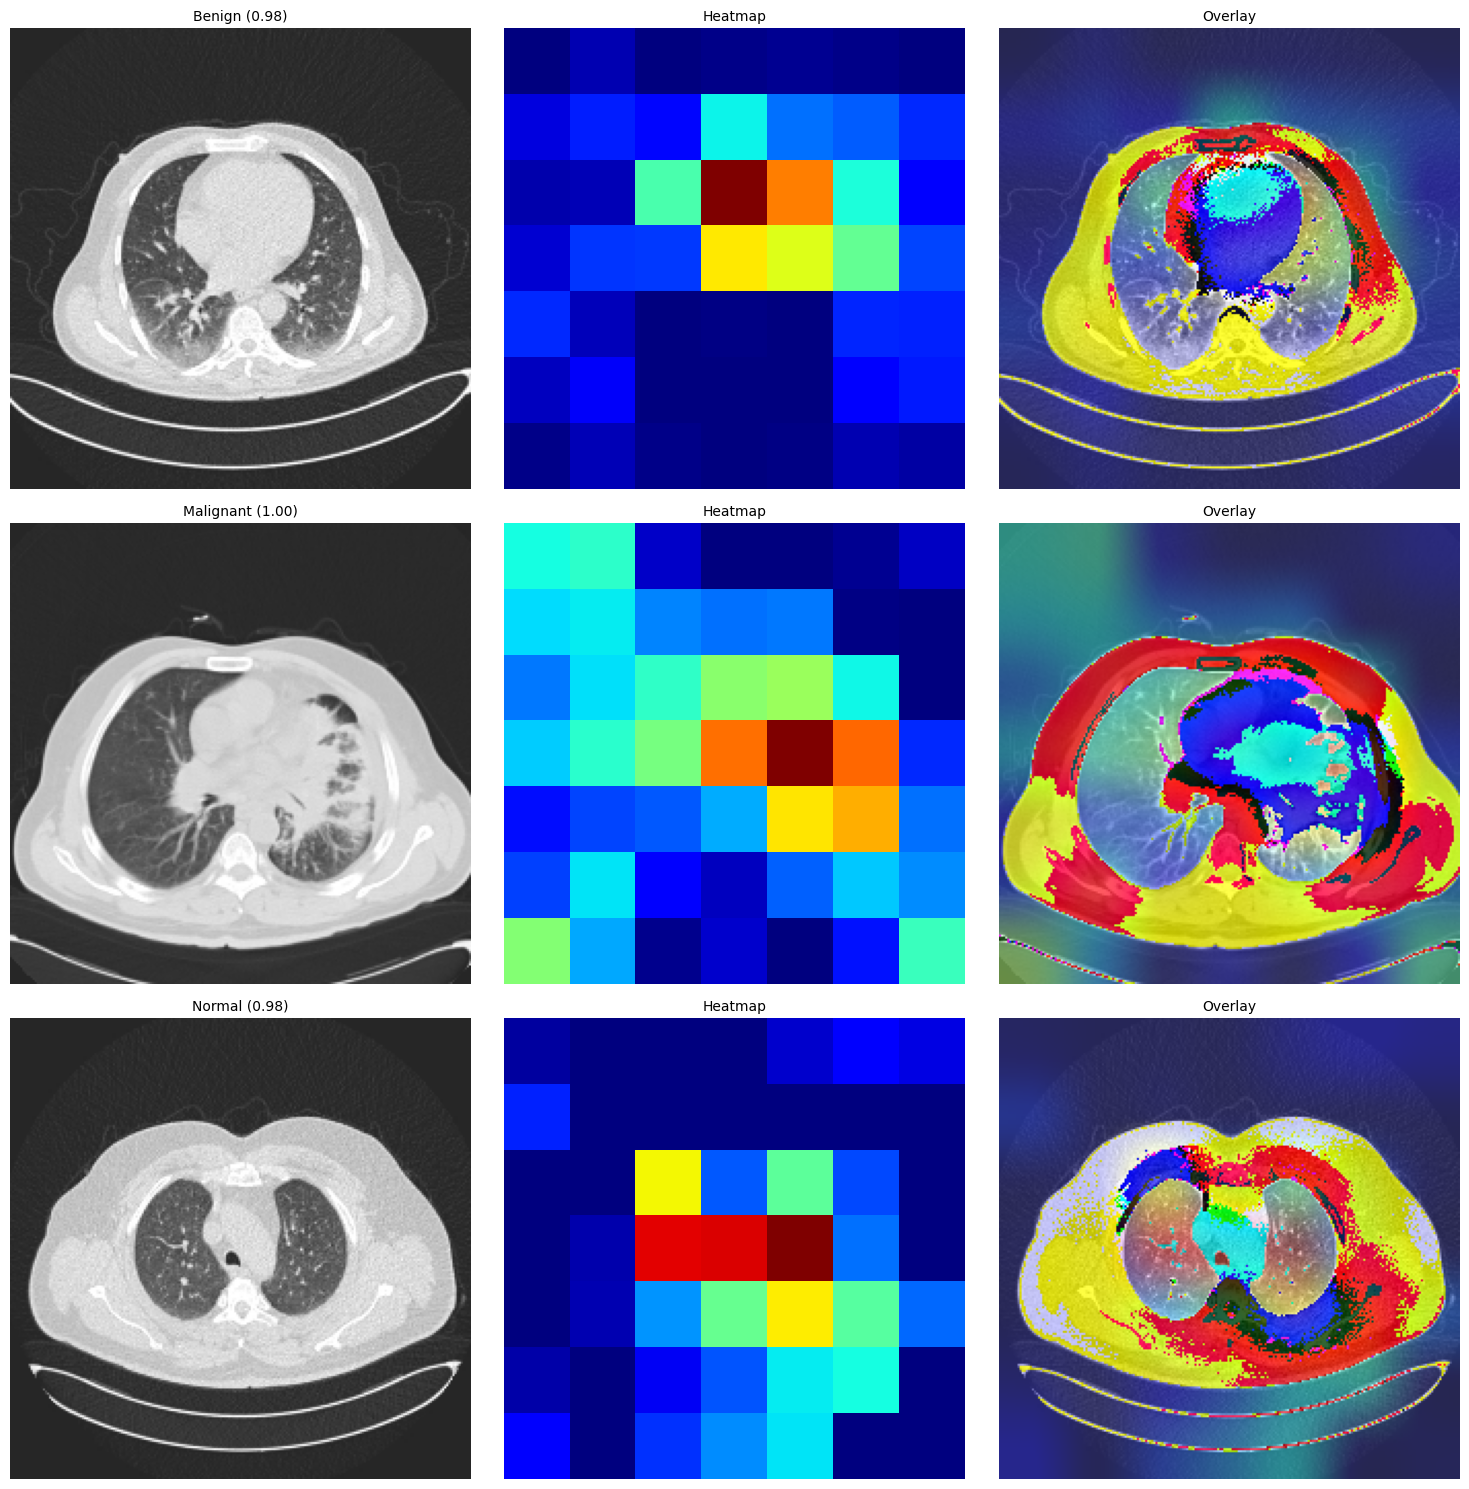

In [27]:
# Compare GradCAM across different classes
print('Comparing GradCAM across classes...')

comparison_images = []
for label in labels:
    class_path = os.path.join(dataset_path, label)
    class_files = os.listdir(class_path)
    if class_files:
        comparison_images.append(os.path.join(class_path, class_files[0]))

if comparison_images:
    batch_gradcam_visualization(comparison_images, model, last_conv_layer_name, labels)
else:
    print('No images found for comparison!')

In [28]:
def save_gradcam_visualization(image_path, model, last_conv_layer_name, save_path):
    """
    Generate and save GradCAM visualization to file.

    Args:
        image_path: Path to input image
        model: Trained Keras model
        last_conv_layer_name: Name of last convolutional layer
        save_path: Path to save the output
    """
    # Load and process image
    img = load_img(image_path)
    img = np.array(img)
    img_resized = cv2.resize(img, (224, 224))
    img_array = np.expand_dims(img_resized, axis=0)

    # Generate GradCAM
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

    # Create visualization
    heatmap_uint8 = np.uint8(255 * heatmap)
    jet = plt.cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_uint8]
    jet_heatmap = keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((224, 224))
    jet_heatmap = keras.preprocessing.image.img_to_array(jet_heatmap)
    superimposed_img = jet_heatmap * 0.4 + img_resized

    # Plot and save
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img_resized.astype('uint8'))
    axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(heatmap_uint8, cmap='jet')
    axes[1].set_title('GradCAM Heatmap', fontsize=12, fontweight='bold')
    axes[1].axis('off')

    axes[2].imshow(superimposed_img.astype('uint8'))
    axes[2].set_title('GradCAM Overlay', fontsize=12, fontweight='bold')
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()

    print(f'Saved GradCAM visualization to: {save_path}')

print('Save function defined!')

# Example: Save the first visualization
# save_gradcam_visualization(query_image_path, model, last_conv_layer_name, 'gradcam_output.png')

Save function defined!
